In [1]:
import pandas as pd
import numpy as np

# 1. Create Synthetic QR Scan Data
n_samples = 1000
data = {
    'hour': np.random.randint(8, 18, n_samples), # Most scans during work hours
    'url_length': np.random.normal(25, 5, n_samples).astype(int),
    'dot_count': np.random.randint(1, 3, n_samples),
    'protocol': np.random.choice(['https', 'http'], n_samples, p=[0.9, 0.1]),
    'label': 0 # Normal
}

df = pd.DataFrame(data)

# 2. Add Anomalies (The 3% Phishing Attacks)
n_attacks = 30
df.loc[:n_attacks-1, 'hour'] = np.random.randint(0, 5, n_attacks) # Late night
df.loc[:n_attacks-1, 'url_length'] = np.random.randint(80, 150, n_attacks) # Long URLs
df.loc[:n_attacks-1, 'dot_count'] = np.random.randint(5, 10, n_attacks) # Many dots
df.loc[:n_attacks-1, 'label'] = 1 # Malicious

print(f"Dataset ready with {len(df)} rows. Anomaly rate: {n_attacks/n_samples*100}%")
df.head()

Dataset ready with 1000 rows. Anomaly rate: 3.0%


,hour,url_length,dot_count,protocol,label
0,1,97,5,https,1
1,0,85,7,https,1
2,3,84,5,https,1
3,1,147,8,http,1
4,1,148,7,http,1


In [2]:
# Show basic stats
print("Dataset Statistics:")
print(df.describe())

# Check the distribution of normal (0) vs malicious (1)
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True) * 100)

Dataset Statistics:
             hour   url_length    dot_count        label
count  1000.00000  1000.000000  1000.000000  1000.000000
mean     12.05300    26.873000     1.659000     0.030000
std       3.34176    16.380268     1.047768     0.170673
min       0.00000     9.000000     1.000000     0.000000
25%      10.00000    21.000000     1.000000     0.000000
50%      12.00000    24.000000     2.000000     0.000000
75%      15.00000    28.000000     2.000000     0.000000
max      17.00000   148.000000     9.000000     1.000000

Class Distribution:
label
0    97.0
1     3.0
Name: proportion, dtype: float64


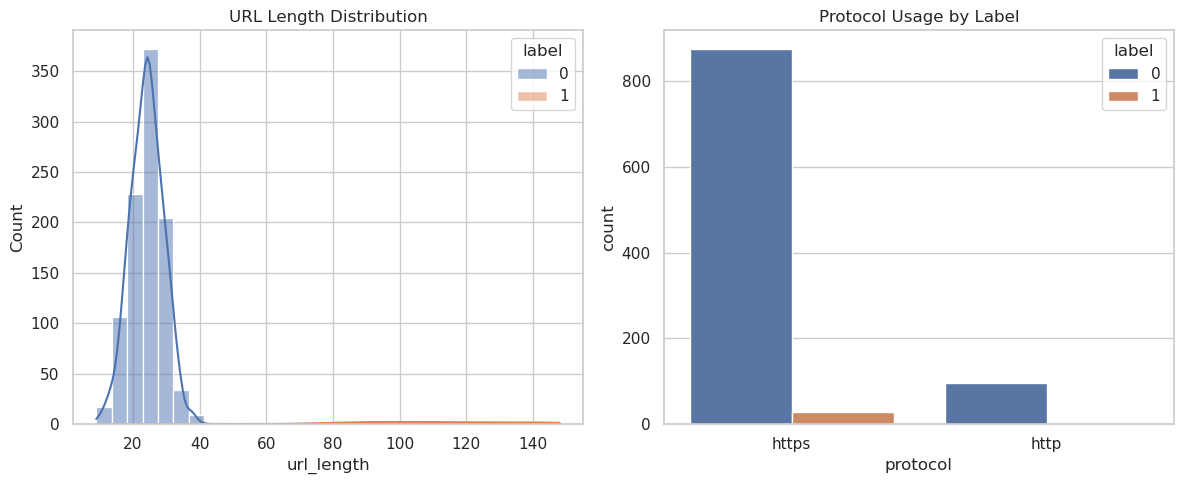

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Visualization 1: Histogram of URL Lengths colored by Label
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='url_length', hue='label', bins=30, kde=True)
plt.title('URL Length Distribution')

# Visualization 2: Count of Protocols used
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='protocol', hue='label')
plt.title('Protocol Usage by Label')

plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest

# Copy the dataframe to keep the original safe
df_model = df.copy()

# Encode categorical feature (protocol)
le = LabelEncoder()
df_model['protocol'] = le.fit_transform(df_model['protocol'])

# Scale the numeric features (hour, url_length, dot_count)
scaler = StandardScaler()
features = ['hour', 'url_length', 'dot_count', 'protocol']
df_model[features] = scaler.fit_transform(df_model[features])

In [6]:
# 1. Initialize the model
iso_forest = IsolationForest(contamination=0.03, random_state=42)

# 2. THE MISSING STEP: Fit the model
# We use .fit() so the model "learns" what normal data looks like
iso_forest.fit(df_model[features])

# 3. Predict scores and labels
# Now that it's fitted, decision_function and predict will work
df['anomaly_score'] = iso_forest.decision_function(df_model[features])
df['predicted_label'] = iso_forest.predict(df_model[features])

# 4. Convert -1/1 to 1/0 to match our original labels
# Isolation Forest: -1 is outlier (anomaly), 1 is inlier (normal)
df['predicted_label'] = df['predicted_label'].map({1: 0, -1: 1})

print("Model training and prediction complete!")

Model training and prediction complete!


Model detected 30 anomalies out of 1000 samples.

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



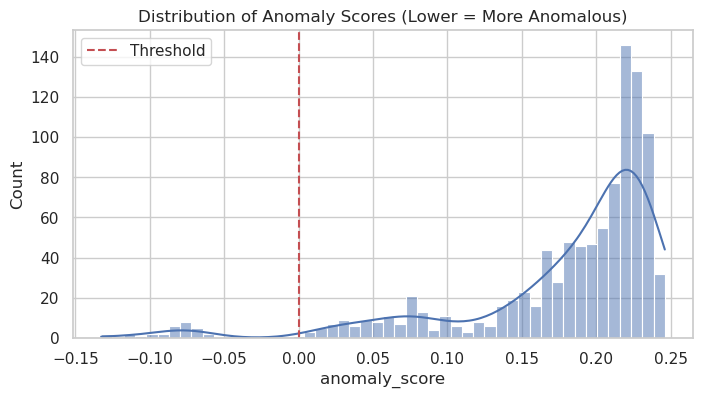

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

# Report how many anomalies were detected
detected_count = df['predicted_label'].sum()
print(f"Model detected {detected_count} anomalies out of {len(df)} samples.")

# Show metrics
print("\nClassification Report:")
print(classification_report(df['label'], df['predicted_label']))

# Visualize Anomaly Scores
plt.figure(figsize=(8, 4))
sns.histplot(df['anomaly_score'], bins=50, kde=True)
plt.axvline(x=0, color='r', linestyle='--', label='Threshold')
plt.title('Distribution of Anomaly Scores (Lower = More Anomalous)')
plt.legend()
plt.show()

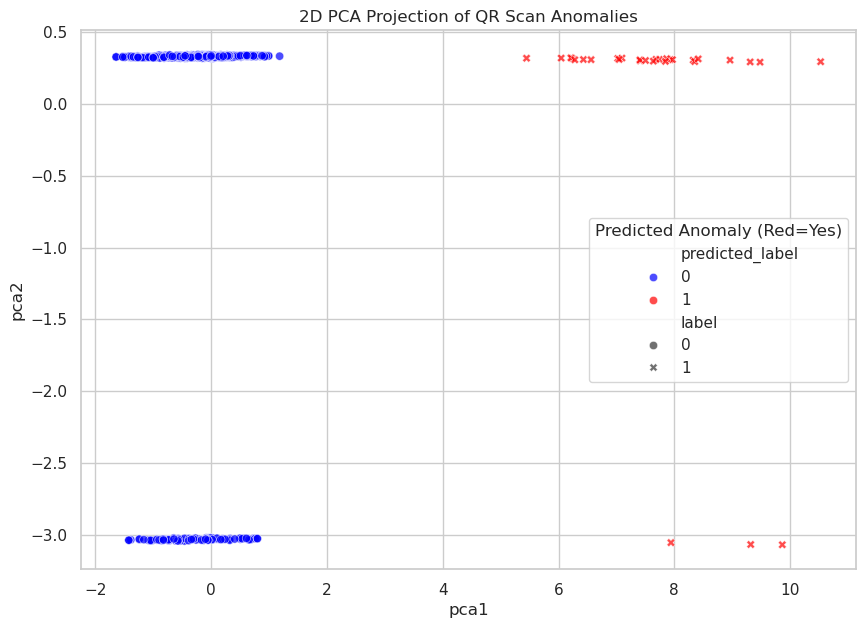

In [8]:
from sklearn.decomposition import PCA

# 1. Initialize PCA to reduce to 2 dimensions
pca = PCA(n_components=2)

# 2. Fit and transform the scaled data
pca_results = pca.fit_transform(df_model[features])

# 3. Add the results to our main dataframe for plotting
df['pca1'] = pca_results[:, 0]
df['pca2'] = pca_results[:, 1]

# 4. Create the scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df, 
    x='pca1', 
    y='pca2', 
    hue='predicted_label', 
    palette={0: 'blue', 1: 'red'},
    style='label', # Original labels to see if they overlap
    alpha=0.7
)

plt.title('2D PCA Projection of QR Scan Anomalies')
plt.legend(title='Predicted Anomaly (Red=Yes)')
plt.show()